# Niwot Snow Report: How did anomalously warm winter conditions alter vertical snowpack structures and temperature gradients at Colorado's Mountain Research Station? 
 
Created by: Anna LaSusa

**Datasets:**

**Fieldwork_near_Niwot_SNOTEL_March4_March27_2026. Snowpit data from Max and Jen from March 4 and 27. https://github.com/annalasusa1/ATOC-4500-Capstone/blob/main/Fieldwork_near_Niwot_SNOTEL_March4_March27_2026.xlsx**

**Variables:** 
* Total snow depth (cm)
* Depth (cm) (vertical position in snowpack)
* Density (kg/m3)
* Snow Temperature (℃) at specific depths
* Crystal size (mm or category)


**hw5_Niwot_SNOTEL_data_1981-2025. Annual SWE measurements from 1981 to 2026. https://github.com/annalasusa1/ATOC-4500-Capstone/blob/main/hw5_Niwot_SNOTEL_data_1981-2025.csv** 

**Variables:** 
* Year
* SWE

**hw5_Niwot_SNOTEL_data_daily_2026_lastupdatedMarch27. Niwot SNOTEL daily data 1981 to 2026. Time series at one location. https://github.com/annalasusa1/ATOC-4500-Capstone/blob/main/hw5_Niwot_SNOTEL_data_daily_2026_lastupdatedMarch27.csv** 

**Variables:** 
* WTEQ::value is SWE (inches of water)
* WTEQ::delta is change in SWE from previous timestamp
* SNWD::value is snow depth (inches)
* SNWD::delta is change in snowdepth


**4 NIWOT_snowtel_20261001-20260327.csv. C1 data 2025-2026 https://github.com/annalasusa1/ATOC-4500-Capstone/blob/main/NIWOT_snowtel_20261001-20260327.csv**

**Variables:**
* Date
* SWE (in) Start of day
* Percipitation Accumulation (in) Start of day
* Air Temperature Maximum (degF)
* Air Temperature Miinimum (degF)
* Percipitation Increment (in)

In [101]:
# import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [97]:
# Read in Jen and Max Fieldwork near Niwot SNOTEL data
df = pd.read_excel("Fieldwork_near_Niwot_SNOTEL_March4_March27_2026.xlsx", header=3)

In [99]:
# Read in hw5 Niwot SNOTEL data daily 2026
df_daily = pd.read_csv("/Users/anna/Library/CloudStorage/OneDrive-UCB-O365/ATOC 4500 Polar Ice/hw5_Niwot_SNOTEL_data_daily_2026_lastupdatedMarch27.csv")

In [177]:
# Read in C1 data
c1= pd.read_csv("NIWOT_snowtel_20261001-20260327.csv")

In [138]:
# Read in NIWOT SNOTEL air temp data
nwtemps = pd.read_csv("/Users/anna/Library/CloudStorage/OneDrive-UCB-O365/ATOC 4500 Polar Ice/NIWOT_snowtel_20261001-20260327.csv")

# Make datetime object
nwtemps["Date"] = pd.to_datetime(snotel["Date"])


**Analyze your data**  
We began by identifying relevant datasets based on variables, timeframes, and location. We then read in and looked through the structure of the data for things like column names, NaN cells, datetime structures. There was an attempt to clean and restructure the CSV from the snow pit data but in the end we identified the values and manually input them into the plots rather than parsing directly from the dataframe. Most plotting code was generated using ChatGPT and specific prompting was focused around accuracy of values, direct comparison of results, as well as clarity and readability of figures. The majority of the analysis was spent identifying what variables were most relevant for comparison, cross referencing datasets to verify results, and conducting literary review with existing studies.

**Present your results visually** 

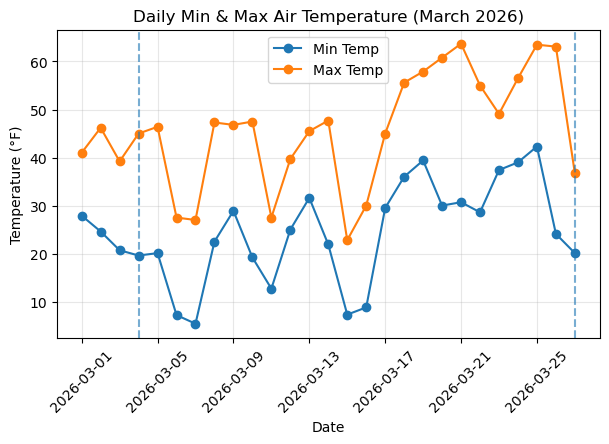

In [286]:
# Minimum and maximum temperatures for March 1-27, 2026 from nwtemps data
fig, ax = plt.subplots(figsize=(7,4))

ax.plot(march["Date"], march["Air Temperature Minimum (degF)"],
        marker="o", label="Min Temp")

ax.plot(march["Date"], march["Air Temperature Maximum (degF)"],
        marker="o", label="Max Temp")

# profile dates
ax.axvline(pd.to_datetime("2026-03-04"), linestyle="--", alpha=0.6)
ax.axvline(pd.to_datetime("2026-03-27"), linestyle="--", alpha=0.6)

ax.set_xlabel("Date")
ax.set_ylabel("Temperature (°F)")
ax.set_title("Daily Min & Max Air Temperature (March 2026)")

plt.xticks(rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()

Figure 1: Temperature from March 1 to March 27 from the SNOTEL site at the Mountain Research Station, located at approximately 9940' in Colorado's Indian Peaks Wilderness.  We see anomolously high temperatures for March with maximums reaching above 60 degrees on numerous days. There were only five days in March that did not see temperatures above freezing. 

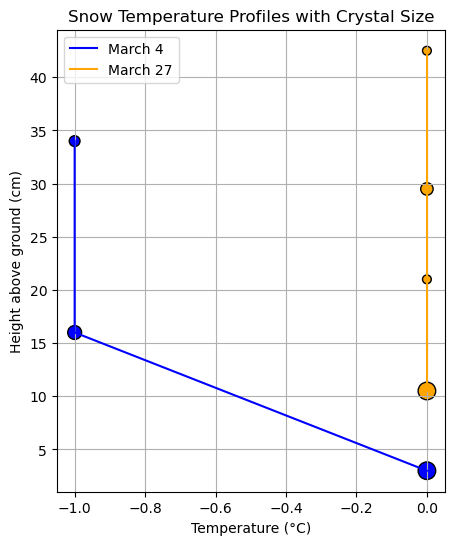

In [353]:
# plot vertical snow temperature profile with crystal sizes
# -----------------------
# March 4 (fixed crystal sizes)
# -----------------------
depth_m4 = [3, 16, 34]
temp_m4 = [0, -1, -1]

# convert crystal sizes using markers
crystal_m4 = [160, 100, 60]  # 2 mm, 1.5 mm, 1 mm

# -----------------------
# March 27 
# -----------------------
depth_m27 = [10.5, 21, 29.5, 42.5]
temp_m27 = [0, 0, 0, 0]
crystal_m27 = [160, 40, 80, 40]

# -----------------------
# Plot
# -----------------------
plt.figure(figsize=(5,6))

# March 4
plt.plot(temp_m4, depth_m4, color='blue', label='March 4')
plt.scatter(temp_m4, depth_m4, s=crystal_m4, color='blue', edgecolors='black')

# March 27
plt.plot(temp_m27, depth_m27, color='orange', label='March 27')
plt.scatter(temp_m27, depth_m27, s=crystal_m27, color='orange', edgecolors='black')

# Labels
plt.xlabel("Temperature (°C)")
plt.ylabel("Height above ground (cm)")
plt.title("Snow Temperature Profiles with Crystal Size")

plt.legend()
plt.grid()

plt.show()

Figure 2: Vertical snow temperature profiles at Niwot Ridge on March 4 and March 27, 2026. March 4 shows a reversed thermal gradient consistent with a net upward energy transfer. Marker sizes show relative crystal sizes between 1-2mm. March 27 shows the profile moved to an isothermal snowpack indicating it's begun the melt process.

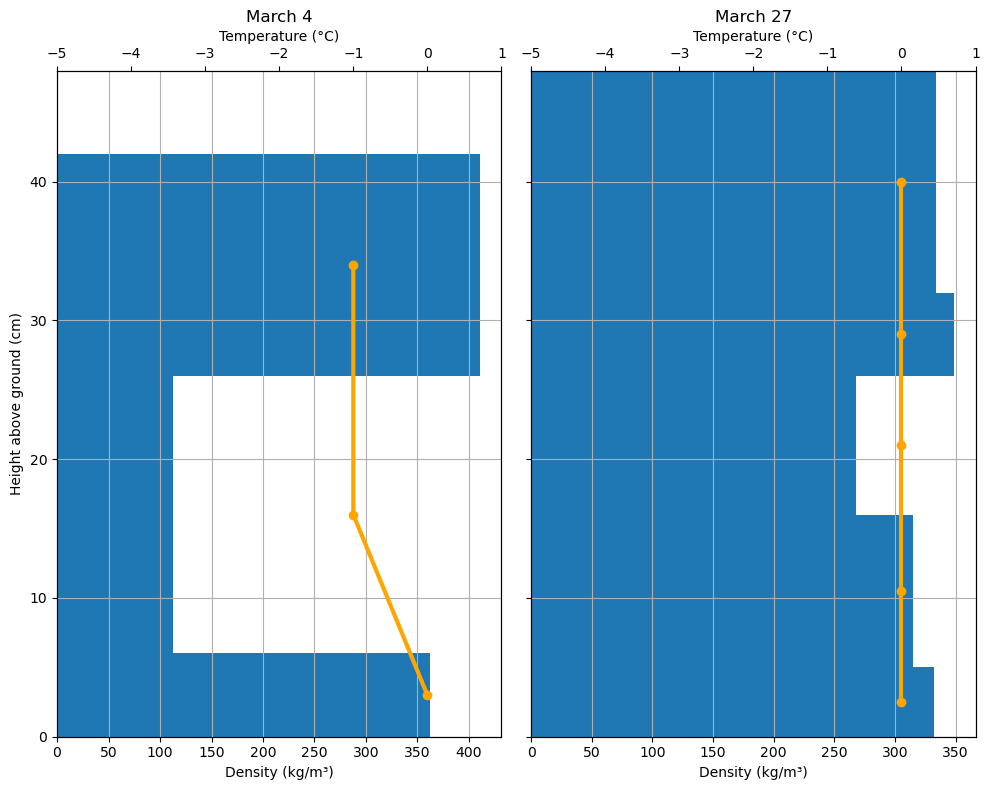

In [347]:
# Density plot based on snowpack layers
# March 4: (bottom, top, density)
m4_layers = [
    (0, 6, 362),
    (6, 26, 113),
    (26, 42, 411)
]

# March 27: interpreting "top X cm" as layer boundary depths from the top
# Total depth = 48 cm
# Convert to height above bottom:
# top 48 -> bottom = 0
# top 43 -> 5
# top 32 -> 16
# top 22 -> 26
# top 16 -> 32
# surface -> 48

m27_layers = [
    (0, 5, 332),
    (5, 16, 315),
    (16, 26, 268),
    (26, 32, 349),
    (32, 48, 334)
]

# Temperatures
m4_temps = [0, -1, -1]
m27_temps = [0, 0, 0, 0, 0]

fig, axes = plt.subplots(1, 2, figsize=(10,8), sharey=True)

# --- March 4 ---
m4_depths = []
for (bottom, top, density), temp in zip(m4_layers, m4_temps):
    axes[0].barh(bottom, density, height=top-bottom, align='edge', color='#1f77b4')
    m4_depths.append(bottom + (top-bottom)/2)

axes[0].set_title("March 4")

ax0_temp = axes[0].twiny()
ax0_temp.plot(m4_temps, m4_depths, color='orange', marker='o', linewidth=3)
ax0_temp.set_xlim(-5, 1)
ax0_temp.set_xlabel("Temperature (°C)")

# --- March 27 ---
m27_depths = []
for (bottom, top, density), temp in zip(m27_layers, m27_temps):
    axes[1].barh(bottom, density, height=top-bottom, align='edge', color='#1f77b4')
    m27_depths.append(bottom + (top-bottom)/2)

axes[1].set_title("March 27")

ax1_temp = axes[1].twiny()
ax1_temp.plot(m27_temps, m27_depths, color='orange', marker='o', linewidth=3)
ax1_temp.set_xlim(-5, 1)
ax1_temp.set_xlabel("Temperature (°C)")

# --- Formatting ---
for ax in axes:
    ax.set_xlabel("Density (kg/m³)")
    ax.grid()
    ax.set_ylim(0, 48)
    ax.margins(y=0)

axes[0].set_ylabel("Height above ground (cm)")

plt.tight_layout()
plt.show()

Figure 3: Density and snow temperature relative to each defined snow layer. On March 4th we see both a low density layer that has means to insulate the snowpack, as well as a reversed thermal gradient. On March 27th we see the snow is significantly more dense, and The snow has moved to isothermal conditions. Strong indication the snowpack has begun the melt process.

**Step 5: Abstract:**  
Anomalously warm winter conditions disrupt snowpack by driving melt, creating shallower snowpacks, shortening the duration of snowcover, and leading to smaller areas of distribution. Warm winter conditions also increase the likelihood of wet loose avalanches even in historically dry, continental snowpacks such as those found in the intermountain west. Colorado sees notoriously unstable snowpacks with frequent deep persistent slab problems characterized by buried weak layers consistent with early season cold, dry conditions. Warm winter conditions shift the regime to now include more dynamic factors by inhibiting snow from retaining SWE, thinning showpacks, and causing larger swings in temperature in short timespans. On average, Colorado snowpack starts its melt process in early April, though this timeframe depends greatly on aspect and elevation. In this research we addressed how anomalously warm winters impact snowpack structures through snow metamorphism by looking at factors like density and snow temperature in vertical snow profiles. In Figure 1 we find that there were only 5 days between March 1 and 27th where the air temperature remained below freezing, and temperatures reached above 32 degrees consistently from March 15th to March 27th. In Figure 2 we identify a reversed thermal gradient on March 4th and through a matter of weeks with temperatures above freezing the snow transitioned to an isothermal snowpack in the advanced stages of melt. We also see larger crystals at the base of the snowpack that are likely facets from early season conditions. The low density snow layer present in the March 4th snowpit (figure 3) had the capacity to act as an insulator and slow the melt process even with consistent above freezing temperatures in March. Despite a deeper snowpack on March 27th the consistent warmer temperatures left us with a high density snowpack in isothermal conditions indicating the warmer temperatures were persistent enough to start the melt process. Additional research needs to be done to understand the reversed thermal gradient effects on vertical snow structures in anomalously warm conditions, in particular with regards to crystal size and shape. Further research could also be done on the insulating effect of low density snow layers in warm conditions.